In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/creditcard.csv")

df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [2]:
X = df.drop(columns=["Class"])
y = df["Class"]

In [3]:
from sklearn.model_selection import train_test_split

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size = 0.2,
    random_state = 42,
    stratify=y)
    

In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [7]:
modelo3 = LogisticRegression(max_iter=100, class_weight="balanced")
modelo3.fit(X_train_scaled, y_train)
previsoes = modelo3.predict(X_test_scaled)
print(classification_report(y_test, previsoes))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



In [8]:
from sklearn.metrics import average_precision_score

probs = modelo3.predict_proba(X_test_scaled)[:, 1]
pr_auc = average_precision_score(y_test, probs)
print(pr_auc)

0.7189705771419241


In [9]:
from imblearn.over_sampling import SMOTE

In [10]:
smote = SMOTE(random_state=42)

In [11]:
X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

In [12]:
y_train_sm.value_counts()

Class
0    227451
1    227451
Name: count, dtype: int64

In [13]:
modelo_smote = LogisticRegression(max_iter=1000)
modelo_smote.fit(X_train_sm, y_train_sm)
previsoes = modelo_smote.predict(X_test_scaled)
print(classification_report(y_test, previsoes))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



In [14]:
probs = modelo_smote.predict_proba(X_test_scaled)[:, 1]
print(average_precision_score(y_test, probs))

0.7244694356694709


In [15]:
from sklearn.metrics import precision_recall_curve

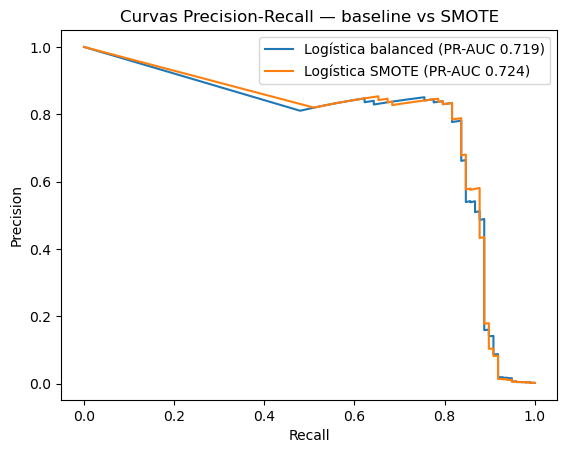

In [16]:
probs_base = modelo3.predict_proba(X_test_scaled)[:, 1]
prec_b, rec_b, _ = precision_recall_curve(y_test, probs_base)
plt.plot(rec_b, prec_b, label="Logística balanced (PR-AUC 0.719)")

probs_sm = modelo_smote.predict_proba(X_test_scaled)[:, 1]
prec_s, rec_s, _ = precision_recall_curve(y_test, probs_sm)
plt.plot(rec_s, prec_s, label="Logística SMOTE (PR-AUC 0.724)")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curvas Precision-Recall — baseline vs SMOTE")
plt.legend()
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train,y_train)
probs_rf = rf.predict_proba(X_test)[:,1]
print(average_precision_score(y_test, probs_rf))

0.8733910547021404


In [18]:
importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias.sort_values(ascending=False).head(10)

V17    0.170325
V14    0.136363
V12    0.133326
V10    0.074073
V16    0.071792
V11    0.045277
V9     0.031127
V4     0.030496
V18    0.028156
V7     0.024627
dtype: float64

In [19]:
(y_train==0).sum()

np.int64(227451)

In [20]:
(y_train==1).sum()

np.int64(394)

In [21]:
227451/394

577.2868020304569

In [22]:
pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [23]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1,
    scale_pos_weight= 577.2868020304569
)

In [27]:
xgb.fit(X_train, y_train)
probs_xgb = xgb.predict_proba(X_test)[:,1]
print(average_precision_score(y_test,probs_xgb))

0.8811805050334162


In [29]:
for t in [0.5, 0.9, 0.99]:
    print(f"--- threshold {t} ---")
    print(classification_report(y_test, (probs_xgb > t).astype(int)))

--- threshold 0.5 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.88      0.84      0.86        98

    accuracy                           1.00     56962
   macro avg       0.94      0.92      0.93     56962
weighted avg       1.00      1.00      1.00     56962

--- threshold 0.9 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.92      0.84      0.88        98

    accuracy                           1.00     56962
   macro avg       0.96      0.92      0.94     56962
weighted avg       1.00      1.00      1.00     56962

--- threshold 0.99 ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.96      0.81      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.90      0.94     56962
weighte